# PNAD Income Analysis

This notebook runs the packaged PNAD income pipeline and exports the reproducible analysis products under `outputs/`.

Install the project once from the repository root with:

```bash
python -m pip install -e ".[notebooks]"
```


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from pnad_income.advanced_inequality import annual_inequality_indices
from pnad_income.advanced_plotting import (
    plot_information_indices,
    plot_primary_indices,
    plot_zanardi,
)
from pnad_income.outputs import export_analysis_outputs
from pnad_income.pipeline import PipelineConfig, pipeline_overview, run_pipeline
from pnad_income.validation import combine_gini_references

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = ROOT / "dados_refined"
OUTPUT_DIR = ROOT / "outputs"
REFERENCE_DIR = ROOT / "metadata" / "gini_references"

CONFIG = PipelineConfig(
    database_path=DATA_DIR,
    start_year=1976,
    end_year=2025,
    apply_manual_outlier_cuts=False,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


## Pipeline


In [2]:
results = run_pipeline(CONFIG)

display(pipeline_overview(results))
display(results.summary)


,metric,value
0,observations,8633809
1,first_year,1976
2,last_year,2025
3,number_of_years,45
4,years_with_effective_income,0
5,manual_outlier_cuts_applied,False
6,ccdf_rows_nominal_adjusted,23340
7,ccdf_rows_habitual_effective,0


,year,total,income_n,income_n_missing,income_n_zero,income_n_positive,income_zero_fraction,income_missing_fraction,income_sum,income_xmin,income_xmax,income_mean,income_median,income_std,income_gini,income_pietra,income_k,income_zanardi,income_top_10_share,income_top_1_share,income_top_0_1_share,income_adj_n,income_adj_n_missing,income_adj_n_zero,income_adj_n_positive,income_adj_zero_fraction,income_adj_missing_fraction,income_adj_sum,income_adj_xmin,income_adj_xmax,income_adj_mean,income_adj_median,income_adj_std,income_adj_gini,income_adj_pietra,income_adj_k,income_adj_zanardi,income_adj_top_10_share,income_adj_top_1_share,income_adj_top_0_1_share
0,1976,148396,148396,0,0,148396,0.0000,0.0000,"335,039,960.0000",1.0000,"999,999.0000","2,257.7425","1,000.0000","8,285.1443",0.6217,0.4709,0.7337,-0.0906,0.5202,0.1827,0.0663,148396,0,0,148396,0.0000,0.0000,"166,713,061.7405",0.4976,"497,591.0785","1,123.4337",497.5916,"4,122.6180",0.6217,0.4709,0.7337,-0.0906,0.5202,0.1827,0.0663
1,1977,193886,193886,0,0,193886,0.0000,0.0000,"1,534,116,623.0000",1.0000,"1,119,000.0000","7,912.4672","1,316.0000","69,386.8430",0.8487,0.7131,0.8471,-0.0223,0.8113,0.6590,0.1265,193886,0,0,193886,0.0000,0.0000,"543,514,816.9135",0.3543,"396,445.1405","2,803.2700",466.2393,"24,582.7317",0.8487,0.7131,0.8471,-0.0223,0.8113,0.6590,0.1265
2,1978,216329,216329,0,0,216329,0.0000,0.0000,"1,577,171,537.0000",1.0000,"1,099,998.0000","7,290.6154","2,000.0000","54,720.4243",0.7683,0.6084,0.7986,-0.0423,0.7034,0.4777,0.1373,216329,0,0,216329,0.0000,0.0000,"403,678,473.8353",0.2560,"281,545.4777","1,866.0396",511.9018,"14,005.7418",0.7683,0.6084,0.7986,-0.0423,0.7034,0.4777,0.1373
3,1979,171371,171371,0,0,171371,0.0000,0.0000,"1,721,207,712.0000",1.0000,"1,029,998.0000","10,043.7513","3,000.0000","58,426.3417",0.7288,0.5661,0.7794,-0.0535,0.6524,0.4006,0.0996,171371,0,0,171371,0.0000,0.0000,"260,532,431.5973",0.1514,"155,906.7401","1,520.2831",454.0982,"8,843.7652",0.7288,0.5661,0.7794,-0.0535,0.6524,0.4006,0.0996
4,1981,479110,472198,6912,0,472198,0.0000,0.0144,"4,834,423,856.1876",0.0909,"830,000.0000","10,238.1286","5,000.0000","17,716.6346",0.5885,0.4418,0.7205,-0.1090,0.4703,0.1259,0.0271,472198,6912,0,472198,0.0000,0.0144,"159,921,173.7798",0.0030,"27,456.1309",338.6740,165.3984,586.0605,0.5885,0.4418,0.7205,-0.1090,0.4703,0.1259,0.0271
5,1982,206845,206845,0,0,206845,0.0000,0.0000,"10,204,981,737.0000",1.0000,"5,150,000.0000","49,336.3714","25,000.0000","88,324.4109",0.5898,0.4420,0.7205,-0.1069,0.4757,0.1290,0.0279,206845,0,0,206845,0.0000,0.0000,"167,590,895.2166",0.0164,"84,575.6644",810.2245,410.5615,"1,450.5040",0.5898,0.4420,0.7205,-0.1069,0.4757,0.1290,0.0279
6,1983,508216,499797,8419,3,499794,0.0000,0.0166,"21,847,634,129.0050",5.0000,"7,000,000.0000","43,713.0157","20,428.5714","81,150.8386",0.5984,0.4519,0.7256,-0.1060,0.4789,0.1325,0.0306,499797,8419,3,499794,0.0000,0.0166,"100,598,147.5227",0.0230,"32,231.7295",201.2780,94.0640,373.6617,0.5984,0.4519,0.7256,-0.1060,0.4789,0.1325,0.0306
7,1984,511389,504543,6846,33,504510,0.0001,0.0134,"62,435,643,305.1187",2.5000,"9,999,998.0000","123,746.9221","60,000.0000","213,075.3072",0.5908,0.4451,0.7221,-0.1073,0.4741,0.1264,0.0256,504543,6846,33,504510,0.0001,0.0134,"87,732,006.1826",0.0035,"14,051.5872",173.8841,84.3095,299.4047,0.5908,0.4451,0.7221,-0.1073,0.4741,0.1264,0.0256
8,1985,519783,514137,5646,0,514137,0.0000,0.0109,"243,010,427,915.4783",4.0000,"75,000,000.0000","472,656.9531","223,333.3333","900,141.4286",0.6021,0.4536,0.7264,-0.1048,0.4838,0.1373,0.0330,514137,5646,0,514137,0.0000,0.0109,"97,686,971.4007",0.0016,"30,149.0060",190.0018,89.7770,361.8449,0.6021,0.4536,0.7264,-0.1048,0.4838,0.1373,0.0330
9,1986,287320,284142,3178,0,284142,0.0000,0.0111,"377,677,011.0303",0.1667,"334,666.6667","1,329.1840",652.2500,"2,830.9574",0.5931,0.4447,0.7219,-0.1068,0.4754,0.1390,0.0372,284142,3178,0,284142,0.0000,0.0111,"80,438,704.9861",0.0355,"71,278.2417",283.0933,138.9180,602.9452,0.5931,0.4447,0.721

## Inequality measures


,year,n,gini,pietra,kolkata,kolkata_excess,pietra_over_kolkata_excess,pietra_over_gini,kolkata_small_g_prediction,pietra_small_g_prediction,gini_poor,gini_rich,delta_gini,zanardi,herfindahl,herfindahl_normalized,shannon_entropy,shannon_inequality,theil,atkinson_0.5
0,1976,148396,0.6217,0.4709,0.7337,0.4674,1.0074,0.7574,0.7331,0.4663,0.3242,0.4654,0.1412,0.0444,0.0001,0.0001,10.9874,0.0773,0.9202,0.3290
1,1977,193886,0.8487,0.7131,0.8471,0.6942,1.0272,0.8403,0.8183,0.6365,0.3902,0.8024,0.4123,0.0629,0.0004,0.0004,9.2454,0.2406,2.9297,0.6824
2,1978,216329,0.7683,0.6084,0.7986,0.5973,1.0186,0.7919,0.7881,0.5762,0.3710,0.6922,0.3212,0.0672,0.0003,0.0003,10.1210,0.1761,2.1635,0.5498
3,1979,171371,0.7288,0.5661,0.7794,0.5589,1.0128,0.7767,0.7733,0.5466,0.3565,0.6320,0.2755,0.0650,0.0002,0.0002,10.3034,0.1451,1.7482,0.4865
4,1981,472198,0.5885,0.4418,0.7205,0.4411,1.0016,0.7507,0.7207,0.4414,0.3338,0.3982,0.0645,0.0221,0.0000,0.0000,12.3748,0.0528,0.6903,0.2847
5,1982,206845,0.5898,0.4420,0.7205,0.4410,1.0023,0.7493,0.7212,0.4424,0.3308,0.4084,0.0776,0.0265,0.0000,0.0000,11.5357,0.0575,0.7040,0.2889
6,1983,499797,0.5984,0.4519,0.7256,0.4512,1.0017,0.7552,0.7244,0.4488,0.3373,0.4024,0.0652,0.0217,0.0000,0.0000,12.3992,0.0551,0.7228,0.2944
7,1984,504543,0.5908,0.4451,0.7221,0.4442,1.0018,0.7534,0.7215,0.4431,0.3295,0.4007,0.0712,0.0242,0.0000,0.0000,12.4358,0.0530,0.6956,0.2862
8,1985,514137,0.6021,0.4536,0.7264,0.4529,1.0015,0.7533,0.7258,0.4516,0.3415,0.4094,0.0679,0.0224,0.0000,0.0000,12.4106,0.0562,0.7396,0.2993
9,1986,284142,0.5931,0.4447,0.7219,0.4438,1.0019,0.7498,0.7224,0.4448,0.3358,0.4076,0.0718,0.0243,0.0000,0.0000,11.8275,0.0581,0.7297,0.2916


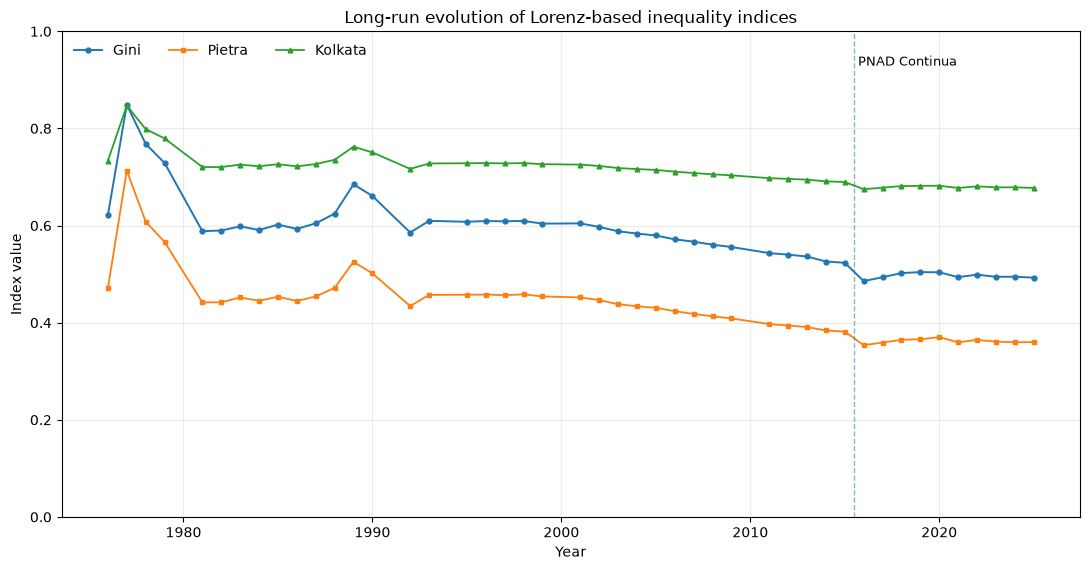

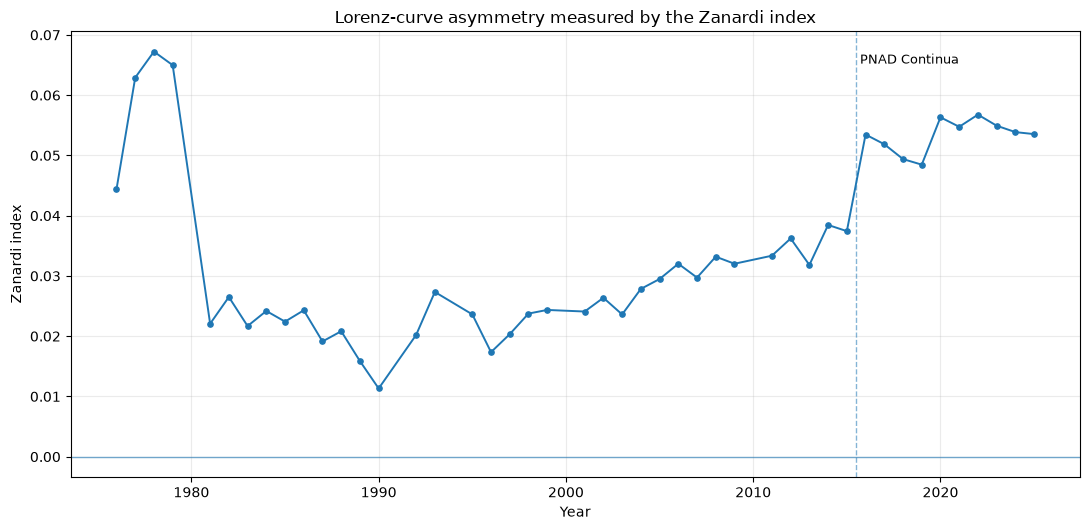

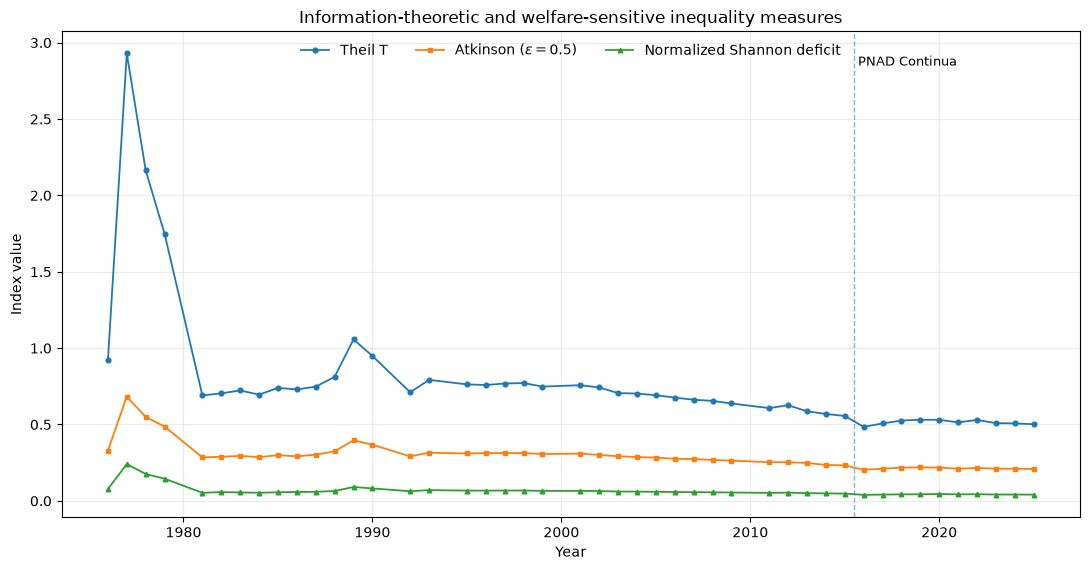

In [3]:
indices = annual_inequality_indices(results.panel, value_col="income", atkinson_epsilon=0.5)
display(indices)

for figure in (
    plot_primary_indices(indices),
    plot_zanardi(indices),
    plot_information_indices(indices),
):
    display(figure)
    plt.close(figure)


## External Gini validation

Any documented CSV files placed in `metadata/gini_references/` are included automatically.


In [4]:
reference_files = sorted(REFERENCE_DIR.glob("*.csv"))
gini_references = (
    combine_gini_references(reference_files)
    if reference_files
    else pd.DataFrame(columns=["year", "gini", "source"])
)

if gini_references.empty:
    print("No external Gini reference CSV files found.")
else:
    display(gini_references)


No external Gini reference CSV files found.


## Export


In [5]:
manifest = export_analysis_outputs(
    results,
    OUTPUT_DIR,
    gini_references=gini_references,
)

display(manifest)


,category,filename,path,size_bytes
0,table,pipeline_overview.csv,C:\Users\Osvaldo\OneDrive\github_oz\pnad_incom...,221
1,table,annual_summary.csv,C:\Users\Osvaldo\OneDrive\github_oz\pnad_incom...,25668
2,table,annual_inequality_indices.csv,C:\Users\Osvaldo\OneDrive\github_oz\pnad_incom...,16729
3,table,ccdf_nominal_adjusted.parquet,C:\Users\Osvaldo\OneDrive\github_oz\pnad_incom...,1409799
4,table,data_quality_diagnostics.csv,C:\Users\Osvaldo\OneDrive\github_oz\pnad_incom...,132
5,figure,gini_income_all_years.png,C:\Users\Osvaldo\OneDrive\github_oz\pnad_incom...,82296
6,figure,top_income_shares_all_years.png,C:\Users\Osvaldo\OneDrive\github_oz\pnad_incom...,119667
7,figure,extended_inequality_pietra_k_z_all_years.png,C:\Users\Osvaldo\OneDrive\github_oz\pnad_incom...,91683
8,figure,inequality_indices_all_years.png,C:\Users\Osvaldo\OneDrive\github_oz\pnad_incom...,119030
9,figure,zanardi_index_all_years.png,C:\Users\Osvaldo\OneDrive\github_oz\pnad_incom...,104160
